# 2D JI-SRT-ERT Gauss Newton Inversion Example

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pygimli.physics.traveltime as tt
from pygimli.viewer.mpl import drawStreams
world = mt.createWorld(
    start=[-50, 0], end=[50, -50], layers=[-1, -5],
    worldMarker=True)
block = mt.createCircle(
    pos=[-5, -3.], radius=[4, 1], marker=4,
    boundaryMarker=10, area=0.1)
poly = mt.createPolygon([(1,-4), (2,-1.5), (4,-2), (5,-2),
                         (8,-3), (5,-3.5), (3,-4.5)], isClosed=True,
                         addNodes=3, interpolate='spline', marker=5)
geom = world + block + poly
scheme = ert.createData(elecs=np.linspace(start=-15, stop=15, num=21),
                           schemeName='dd')
schemeTT = tt.createRAData(scheme.sensors())
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p - [0, 0.1])

# Create a mesh for the finite element modelling with appropriate mesh quality.
mesh_fwd = mt.createMesh(geom, quality=34)

# Create a map to set resistivity values in the appropriate regions
# [[regionNumber, resistivity], [regionNumber, resistivity], [...]
rhomap = [[1, 100.],
          [2, 75.],
          [3, 50.],
          [4, 150.],
          [5, 25]]

velmap = [[1, 500.],
          [2, 1500.],
          [3, 2500.],
          [4, 4000.],
          [5, 300]]

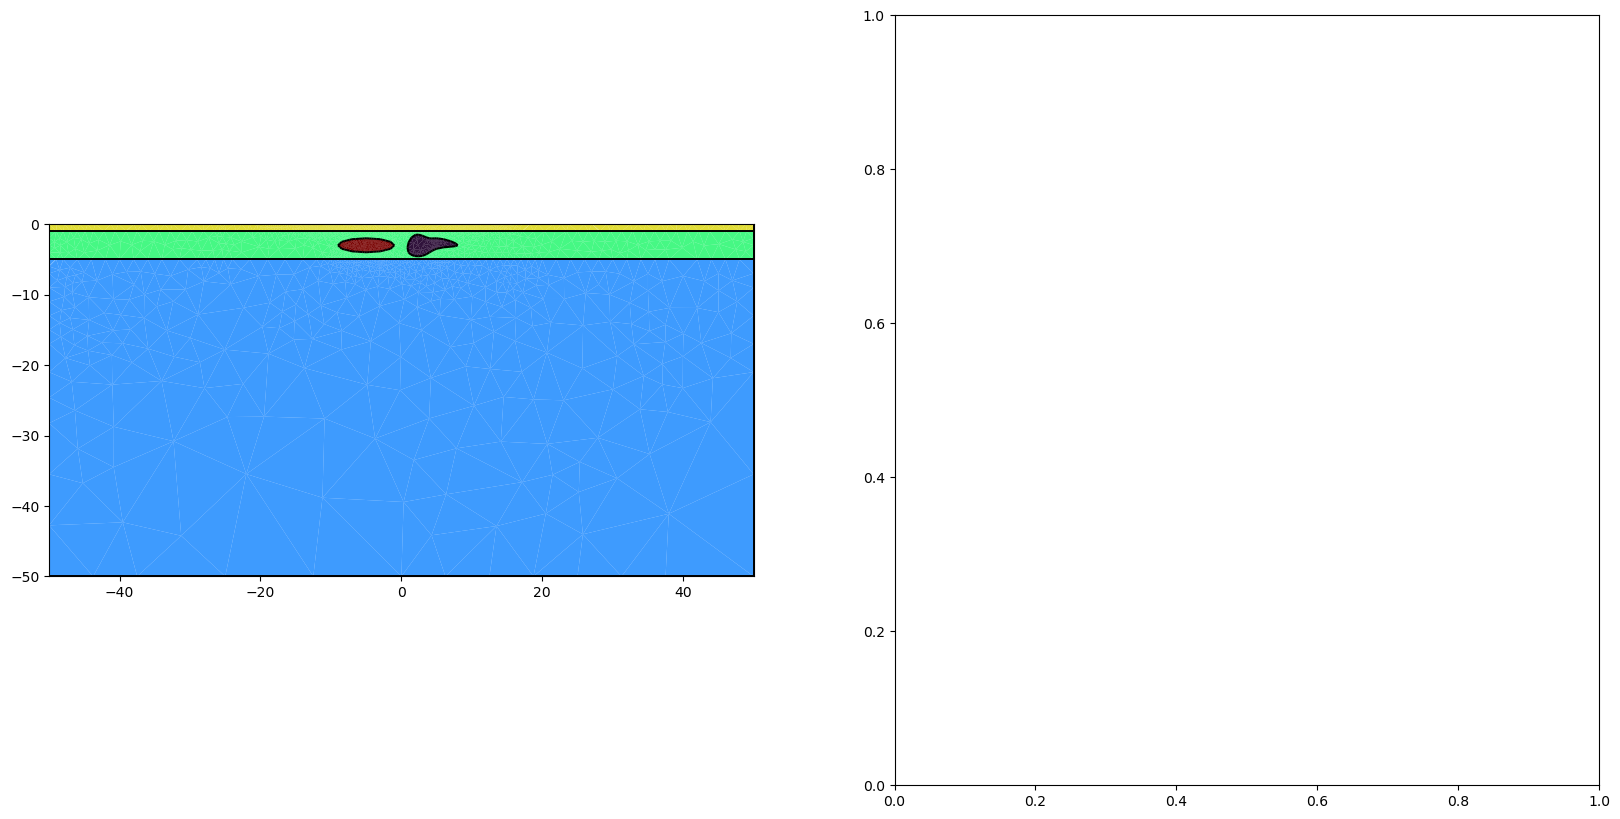

c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:321: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1000 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:321: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1000 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Figure size 640x480 with 0 Axes>

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mesh_fwd, data=rhomap, ax=ax1, label='ρ [Ωm]', pad=0.5, cMap='turbo', showMesh=False)
pg.show(mesh_fwd, data=velmap, ax=ax2, label='v [m/s]', pad=0.5, cMap='magma', showMesh=False)
plt.show()

In [3]:
data_ERT = ert.simulate(mesh_fwd, scheme=scheme, res=rhomap, noiseLevel=1,
                    noiseAbs=1e-6, seed=1337)

data_ERT.remove(data_ERT['rhoa'] < 0)
#pg.info('Filtered rhoa (min/max)', min(data['rhoa']), max(data['rhoa']))
vp = pg.solver.parseMapToCellArray(velmap, mesh_fwd)
data_SRT = tt.simulate(slowness=1.0 / vp, scheme=schemeTT, mesh=mesh_fwd,
                   noiseLevel=0.001, noiseAbs=0.001, seed=1337, verbose=True)

# You can save the data for further use
data_ERT.save('simple.dat')
mgr = ert.ERTManager('simple.dat')
plc = mt.createParaMeshPLC(data_ERT, paraDepth=15, paraMaxCellSize=3, paraBoundary=5, boundary=1)
mesh = mt.createMesh(plc, quality=34.3)

18/09/26 - 13:04:03 - pyGIMLi - INFO - Data error estimate (min:max)  0.010000294838286121 : 0.01056761917552525
18/09/26 - 13:04:03 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
min/max t: 0.003 0.019682262270470208


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

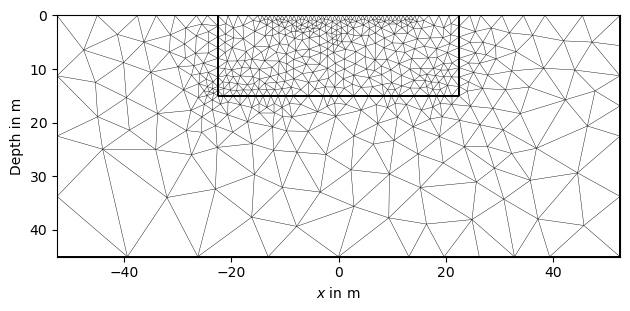

In [4]:
pg.show(mesh, markers=False)

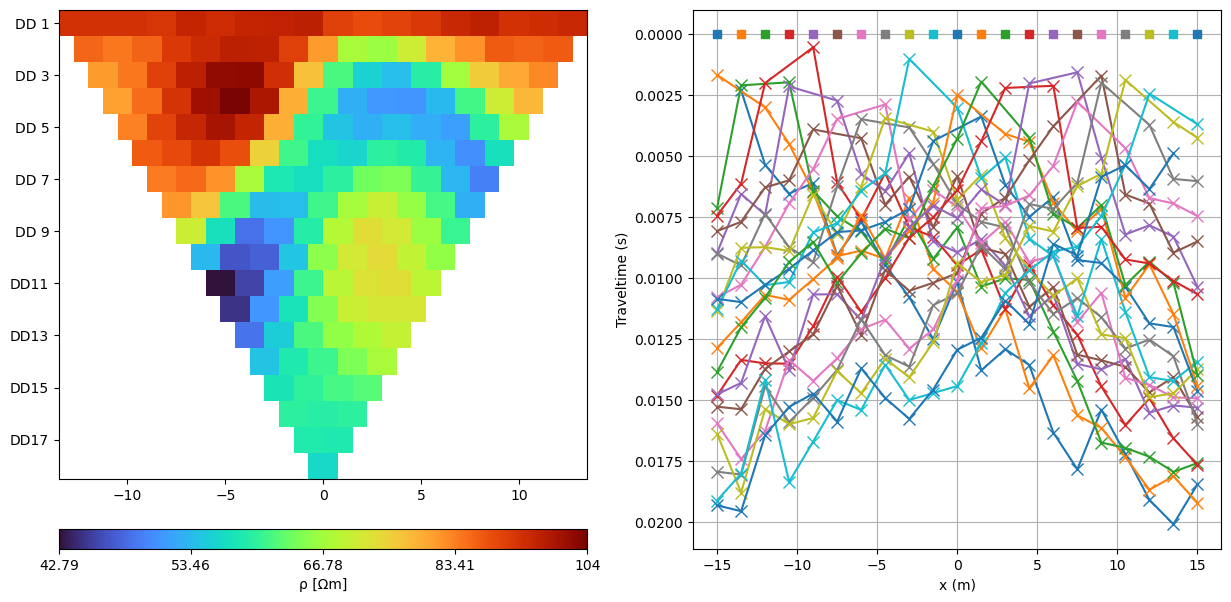

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
pg.show(data_ERT, ax=ax1, label='ρ [Ωm]', cMap='turbo', showMesh=False)
tt.show(data_SRT, ax=ax2, label='v [m/s]')

In [6]:
mgr_ERT = ert.ERTManager(data_ERT)
mgr_ERT.setMesh(mesh)
#pg.show(mgr_ERT.paraDomain)

18/09/26 - 13:04:05 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 13:04:05 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


In [7]:
inv_ERT = mgr_ERT.invert(maxIter=20, mesh=mesh, verbose=True)

18/09/26 - 13:04:05 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 13:04:05 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
18/09/26 - 13:04:05 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:04:05 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/09/26 - 13:04:06 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2091 Cells: 4016 Boundaries: 3094
18/09/26 - 13:04:06 - pyGIMLi - INFO - Use median(data values)=67.9439561191829
18/09/26 - 13:04:06 - pyGIMLi - INFO - Created startmodel from forward operator:614, min/max=67.943956/67.943956
18/09/26 - 13:04:06 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000027F7F907E70>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 42.79/104
min/max (error): 1%/1.06%
min/max (start model): 67.94/67.94
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  506.26
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   18.02 (dPhi = 96.28%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    0.94 (dPhi = 90.83%) lam: 20.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.94)                   #
################################################################################


In [17]:
meshSRT = mgr_ERT.paraDomain
for c in meshSRT.cells():
    c.setMarker(2)
mgr_SRT = tt.TravelTimeManager(data_SRT)
inv_SRT = mgr_SRT.invert(mesh=meshSRT,maxIter=20, verbose=True)

18/09/26 - 13:50:41 - pyGIMLi - INFO - Found 1 regions.
18/09/26 - 13:50:41 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:50:41 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
18/09/26 - 13:50:41 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
18/09/26 - 13:50:41 - pyGIMLi - INFO - Created startmodel from forward operator:614, min/max=0.000200/0.002000
18/09/26 - 13:50:41 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x0000027F7F938C70>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 5.4e-04/0.02
min/max (error): 5.08%/187%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =    4.66
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    1.18 (dPhi = 68.96%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.05 (dPhi = 8.68%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.03 (dPhi = 2.41%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.02 (dPhi = 0.86%) lam: 20.0
#################################################################

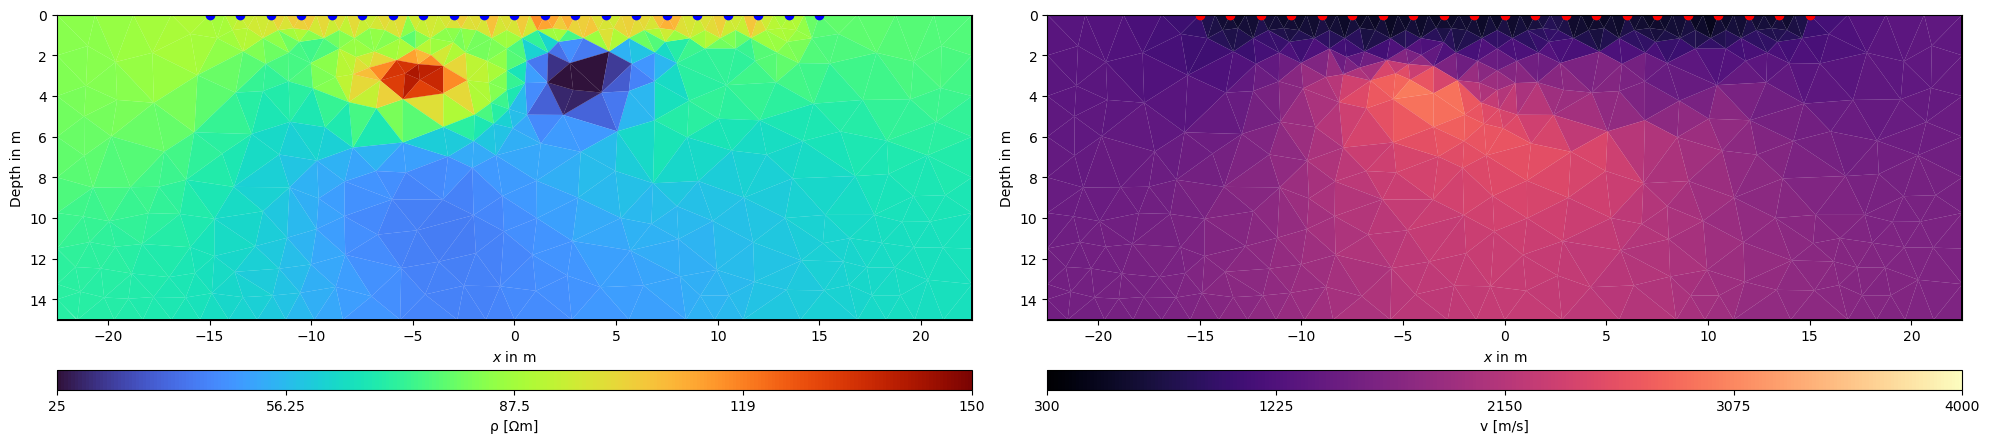

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mgr_ERT.paraDomain, data=inv_ERT, ax=ax1, label='ρ [Ωm]', cMap='turbo', cMin=25, cMax=150,showMesh=False)
pg.show(mgr_SRT.paraDomain, data=inv_SRT, ax=ax2, label='v [m/s]', cMap='magma', cMin=300, cMax=4000, showMesh=False)
ax1.scatter(scheme.sensors()[:,0], scheme.sensors()[:,1], color='blue')
ax2.scatter(schemeTT.sensors()[:,0], schemeTT.sensors()[:,1], color='red')

In [19]:
import jointtools.JItools as JI

crossfop = JI.crossGradient(
    fopList=[mgr_ERT.fop, mgr_SRT.fop], 
    dataList=[data_ERT['rhoa'], data_SRT['t']], 
    errorList=[data_ERT['err'], data_SRT['err']/data_SRT['t']], 
    meshList=[mesh, meshSRT],
    alpha = 1,
    smooth = False
    )

18/09/26 - 13:50:52 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 13:50:52 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
18/09/26 - 13:50:52 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:50:52 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/09/26 - 13:50:52 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2091 Cells: 4016 Boundaries: 3094
18/09/26 - 13:50:52 - pyGIMLi - INFO - Found 1 regions.
18/09/26 - 13:50:52 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:50:52 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


In [20]:
dataVec = np.concatenate((np.array(data_ERT['rhoa']), np.array(data_SRT['t'])))
errorVec = np.concatenate((np.array(data_ERT['err']), np.array(data_SRT['err']/data_SRT['t'])))

In [21]:
startmodel_ERT = mgr_ERT.fop.createStartModel(data_ERT['rhoa'])
startmodel_SRT = mgr_SRT.fop.createStartModel(data_SRT['t'])

startmodel = np.concatenate([startmodel_ERT,startmodel_SRT])

18/09/26 - 13:50:52 - pyGIMLi - INFO - Use median(data values)=67.9439561191829
18/09/26 - 13:50:52 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


In [22]:
import pygimli.frameworks.inversion as inversion
inv = inversion.GaussNewtonInversion(fop=crossfop)
modelGN = inv.run(dataVals=dataVec, errorVals=errorVec, startModel=startmodel, verbose=True)
print('Final \u03C7\u00B2 = ', inv.chi2())

18/09/26 - 13:50:52 - pyGIMLi - INFO - Starting inversion.


fop: <jointtools.JItools.crossGradient object at 0x0000027F7F2F3470>
Data transformation: Identity transform
Model transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 5.4e-04/104
min/max (error): 1%/187%
min/max (start model): 2.0e-04/67.94
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  145.62
--------------------------------------------------------------------------------
inv.iter 1 ... dM:  1228 [0.5133493967434531,...,0.22500616345656094]
tau:  0.8515
chi² =    2.90 (dPhi = nan%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... dM:  1228 [-0.03870630383398612,...,0.11726843162767002]
tau:  0.9505
chi² =    0.95 (dPhi = 36.42%) lam: 20.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.95)                   #
###################################

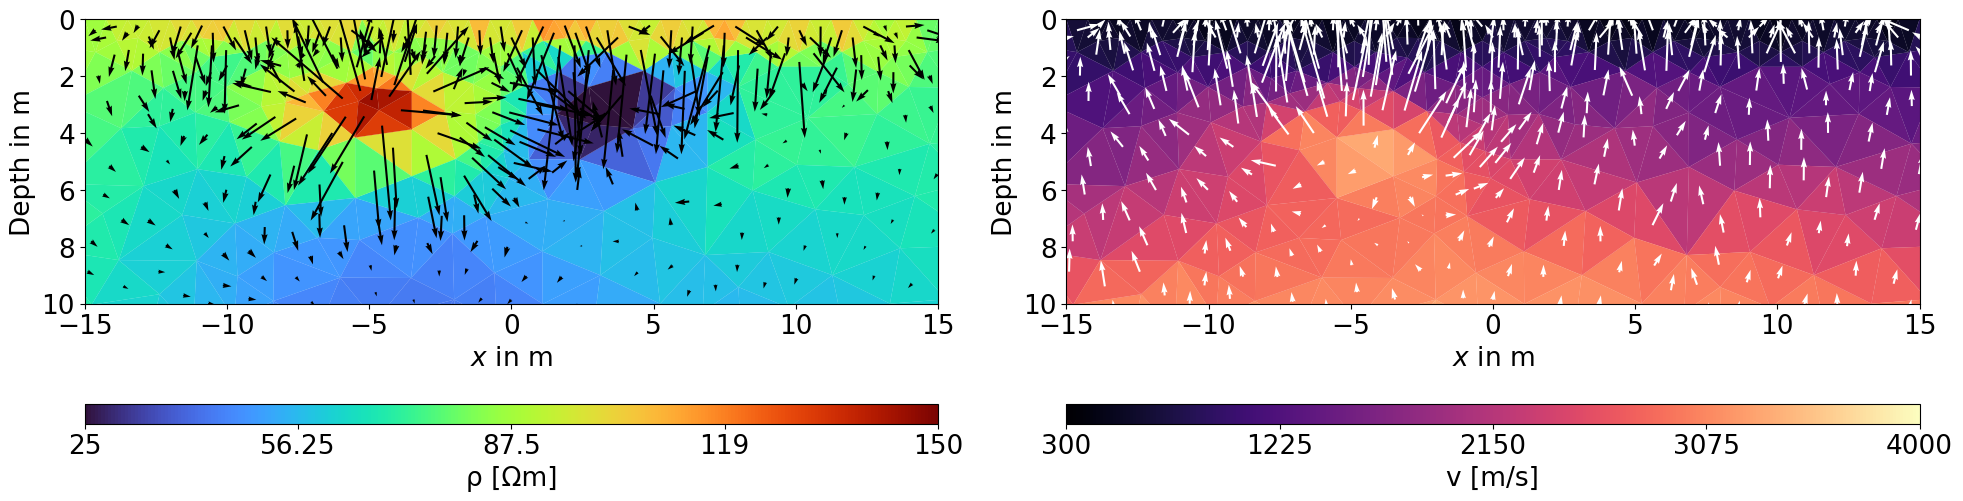

In [40]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(20, 10))
plt.rcParams.update({'font.size': 19})
pg.show(meshSRT, data=np.split(modelGN,2)[0], ax=ax1, cMap='turbo', cMin=25, cMax=150, pad=1, label='ρ [Ωm]', colorBar=True,  logScale=False)
pg.show(meshSRT, data=1/np.split(modelGN,2)[1], ax=ax2, cMap='magma', cMin=300, cMax=4000, pad=1, label='v [m/s]', colorBar=True,  logScale=False)
drawStreams(ax1, meshSRT, gradERT, color='black', quiver=True)
drawStreams(ax2, meshSRT, gradSRT, color='white', quiver=True)
for ax in [ax1, ax2]:
    ax.set_ylim(-10, 0)
    ax.set_xlim(-15, 15)
fig.savefig('../slides/images/joint_inversion_gradients.png', dpi=300, bbox_inches='tight')

In [26]:
nodedataERT  = pg.meshtools.cellDataToNodeData(meshSRT, np.split(modelGN,2)[0])
nodedataSRT = pg.meshtools.cellDataToNodeData(meshSRT, 1/np.split(modelGN,2)[1])#modelCGLSCD

gradERT  = -pg.solver.grad(meshSRT, nodedataERT)
gradSRT = -pg.solver.grad(meshSRT, nodedataSRT)